In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../"))

from src.lyap import LyapunovExponents, NN_LyapExp

In [21]:
A = torch.tensor([[-2.0]])

In [22]:
def f_linear(x):
    if x.ndim == 1:
        x = x.unsqueeze(0)  # optional, depends on your implementation
    y = A @ x
    return y.squeeze(0)

def f_nl(x):
    if x.shape[0] != 2:
        raise ValueError("Expected a 2D state vector (size 2), got shape{}".format(x.shape))
    
    return np.array([x[0] - x[0]**3,
                    -x[1]])

In [23]:
class LinearModel:
    def __call__(self, x, t0=None, t1=None):
        dt = 1.0 if t1 is None else t1 - t0
        expA = torch.matrix_exp(A * dt)
        return expA * x
    
linear_model = LinearModel()

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [24]:
lyap_computer_qr = LyapunovExponents(
    dim=1,
    dt=1e-3,
    continuous=True,
    integrator='rk4'
)

lyap_computer_svd = NN_LyapExp(linear_model)

x0 = torch.tensor([1.0], device=device)

T_values = torch.linspace(1.0, 40.0, 20, device=device)
lyap_estimates = torch.zeros((len(T_values), 1), device=device)
lyap_estimates_svd = torch.zeros((len(T_values), 1), device=device)
lyap_estimates_svd_fd = torch.zeros((len(T_values), 1), device=device)

times_qr = []
times_svd = []
times_svd_fd = []

for i, T in enumerate(T_values):
    start = time.perf_counter()

    lams = lyap_computer_qr.compute(f_linear, x0, T=T.item())
    lyap_estimates[i, :] = torch.as_tensor(lams, device=device)

    end = time.perf_counter()
    elapsed = end - start

    times_qr.append(elapsed)

    # start_svd = time.perf_counter()
    
    # J = lyap_computer_svd.jacobian_flow(x0, t0=0, t1=T).double()
    # # if J.ndim == 0 or J.shape[0] == 1:
    # #     J = J.reshape(1, 1)  # ensure 2D
    # # lams_svd = torch.log(torch.linalg.svdvals(J)) / T
    # if J.ndim == 0:        # scalar 1D case
    #     lams_svd = torch.tensor([torch.log(torch.abs(J)).double() / T], device=device)
    # else:
    #     lams_svd = torch.log(torch.linalg.svdvals(J)) / T

    # lyap_estimates_svd[i, :] = torch.as_tensor(lams_svd, device=device) 

    # end = time.perf_counter()
    # elapsed = end - start_svd
    
    # times_svd.append(elapsed)

    # start_fd = time.perf_counter()
    
    # J_fd = lyap_computer_svd.jacobian_flow_fd(x0, t0=0, t1=T).double()
    # # if J.ndim == 0 or J.shape[0] == 1:
    # #     J = J.reshape(1, 1)  # ensure 2D
    # # lams_svd = torch.log(torch.linalg.svdvals(J)) / T
    # if J_fd.ndim == 0:        # scalar 1D case
    #     lams_svd = torch.tensor([torch.log(torch.abs(J_fd)).double() / T], device=device)
    # else:
    #     lams_svd = torch.log(torch.linalg.svdvals(J_fd)) / T

    # lyap_estimates_svd_fd[i, :] = torch.as_tensor(lams_svd, device=device) 

    # end_fd = time.perf_counter()
    # elapsed_fd = end_fd - start_fd
    
    # times_svd_fd.append(elapsed_fd)



In [54]:
# # --- Initialize the Lyapunov calculator ---
# lyap_calc = LyapunovExponents(dim=2, dt=1e-3, continuous=True, integrator='rk4')

# # --- Range of integration times to test ---
# T_values = np.linspace(1.0, 50, 20)  # from 1 to 50 in 20 steps
# lyap_estimates = np.zeros((len(T_values), 2))

# x0 = np.array([0.8, 0.0])

# # --- Loop over T and compute Lyapunov exponents ---
# for i in range(len(T_values)):
#     lams = lyap_calc.compute(f_nl, x0, T=T_values[i])
#     lyap_estimates[i, :] = lams

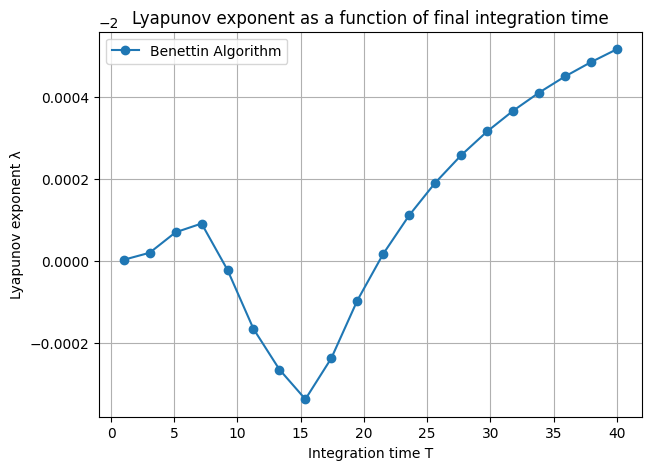

In [25]:
T_np = T_values.detach().cpu().numpy()
lyap_qr_np = lyap_estimates.detach().cpu().numpy()
lyap_svd_np = lyap_estimates_svd.detach().cpu().numpy()

plt.figure(figsize=(7,5))
plt.plot(T_values, lyap_estimates[:, 0], 'o-', label='Benettin Algorithm')
# plt.plot(T_values, lyap_estimates_svd[:, 0], 'o-', label='SVD Algorithm (autograd)')
# plt.plot(T_values, lyap_estimates_svd_fd[:, 0], 'o-', label='SVD Algorithm (finite differences)')
# plt.axhline(2.0, color='r', linestyle='--', label='Analytical Lyapunov exponent')
# plt.plot(T_values, lyap_estimates[:, 1], 'o-', label="Estimated second Lyapunov exponent")
# plt.axhline(-1.0, color='g', linestyle='--', label='Analytical second Lyapunov exponent')

# ymin = lyap_qr_np[:, 0].min()
# ymax = lyap_qr_np[:, 0].max()
# plt.ylim(ymin - 0.01, ymax + 0.01)
plt.xlabel("Integration time T")
plt.ylabel("Lyapunov exponent λ")
plt.title("Lyapunov exponent as a function of final integration time")
plt.legend()
plt.grid(True)
plt.show()

In [51]:
print(T_values)

tensor([ 1.0000,  3.0526,  5.1053,  7.1579,  9.2105, 11.2632, 13.3158, 15.3684,
        17.4211, 19.4737, 21.5263, 23.5789, 25.6316, 27.6842, 29.7368, 31.7895,
        33.8421, 35.8947, 37.9474, 40.0000])


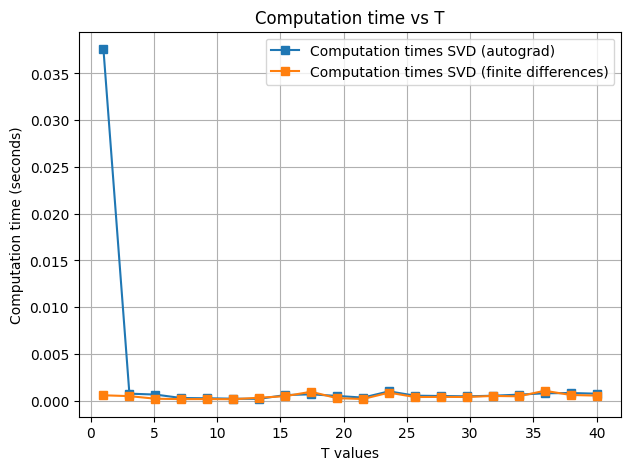

In [ ]:
plt.figure(figsize=(7, 5))

# plt.plot(T_values, times_qr, 'o-', label="Computation times Benettin")
plt.plot(T_values, times_svd, 's-', label="Computation times SVD (autograd)")
plt.plot(T_values, times_svd_fd, 's-', label="Computation times SVD (finite differences)")


plt.xlabel('T values')
plt.ylabel('Computation time (seconds)')
plt.title('Computation time vs T')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
def f_6(x, t):
    if x.shape[0] != 2:
        raise ValueError("We need the state to be two dimensional, with the third dimension being a time augmentation")
    
    x1, x2 = x
    t_tensor = torch.tensor(t, dtype=x.dtype, device=x.device)

    fx1 = torch.cos(4*t_tensor) * x1 + (torch.sin(4*t_tensor) - 2) * x2
    fx2 = (torch.sin(4*t_tensor) + 2) * x1 - x2 * torch.cos(4*t_tensor)
    # fx3 = torch.tensor(1.0, dtype=x.dtype)

    return torch.stack([fx1, fx2])

def jac(x):
    if x.shape[0] != 3:
        raise ValueError("We need the state to be three dimensional, with the third dimension being a time augmentation")
    
    x1, x2, t = x
    J = np.array([
        [np.cos(4*t), np.sin(4*t) - 2, -4 * x1 * np.sin(4*t) + 4 * x2 * np.cos(4*t)],
        [np.sin(4*t) + 2, -np.cos(4*t), 4 * x1 * np.cos(4*t) + 4 * x2 * np.sin(4*t)],
        [0, 0, 0]
        ])
    return J

def jac_ag(x, t):

    x = x.clone().detach().requires_grad_(True)

    def f_local(x):
        return f_6(t, x)

    J = torch.autograd.functional.jacobian(f_local, x)

    return J


In [50]:
class FlowModel:
    def __init__(self, f, steps=100):
        self.f = f
        self.steps = steps

    def __call__(self, x, t0=0.0, t1=1.0):
        dt = (t1 - t0)/self.steps
        y = x.clone() 

        with torch.no_grad():
            t = torch.tensor(t0, dtype=y.dtype, device=y.device)
            dt = torch.tensor(dt, dtype=y.dtype, device=y.device)
            
        for _ in range(self.steps):
            f_eval = self.f(y, t)
            y = y + dt * f_eval
            t=t+dt
            # If your state includes time, update y[-1] = t
        return y
    
# flow_fs = FlowModel(f_6)

In [51]:
class TrueFlowModel:
    """
    Analytical flow map for the system:
        x1(t) = x10*exp(t)*cos(2t) - x20*exp(t)*sin(2t)
        x2(t) = x10*exp(-t)*sin(2t) + x20*exp(-t)*cos(2t)
    """
    def __init__(self):
        pass  # no parameters

    def __call__(self, x, t0=0.0, t1=1.0):
        """
        Compute x(t1) given x(t0) analytically.
        """
        x = x.clone().double()  # ensure float64 for stability
        x0, y0 = x[0], x[1]

        # Time difference
        dt = t1 - t0

        # Compute analytical flow
        exp_p = torch.exp(dt)
        exp_m = torch.exp(-dt)
        cos2t = torch.cos(2*dt)
        sin2t = torch.sin(2*dt)

        x1 = x0 * exp_p * cos2t - y0 * exp_m * sin2t
        x2 = x0 * exp_p * sin2t + y0 * exp_m * cos2t

        return torch.stack([x1, x2])

In [72]:
T_values = torch.linspace(0.1, 50, 20)  # from 1 to 50 in 20 steps

lyap_calc_qr = LyapunovExponents(dim=2, dt=1e-3, continuous=True, integrator='rk4')

true_flow = TrueFlowModel()

# lyap_computer_svd = NN_LyapExp(flow_fs)
lyap_computer_svd = NN_LyapExp(true_flow)

x0 = torch.tensor([4.2, 7.9], dtype=torch.double, requires_grad=True)
# x_aug = torch.cat([x0, torch.tensor([0.0])], dim=0)   

lyap_estimates_qr = torch.zeros((len(T_values), 2))
lyap_estimates_svd = torch.zeros((len(T_values), 2), device=device)
lyap_estimates_svd_unk = torch.zeros((len(T_values), 2), device=device)

times_qr = []
times_svd = []
times_svd_unk = []
# times_svd_fd = []

for i, T in enumerate(T_values):
    start = time.perf_counter()

    lams = lyap_calc_qr.compute(f_6, x0, T=T.item())
    lyap_estimates_qr[i, :] = torch.as_tensor(lams, device=device)

    end = time.perf_counter()
    elapsed = end - start

    times_qr.append(elapsed)
    
    start_svd = time.perf_counter()
    
    J = lyap_computer_svd.jacobian_flow(x0, t0=0, t1=T).double()
    # if J.ndim == 0 or J.shape[0] == 1:
    #     J = J.reshape(1, 1)  # ensure 2D
    # lams_svd = torch.log(torch.linalg.svdvals(J)) / T
    if J.ndim == 0:        # scalar 1D case
        lams_svd = torch.tensor([torch.log(torch.abs(J)).double() / T], device=device)
    else:
        lams_svd = torch.log(torch.linalg.svdvals(J)) / T

    lyap_estimates_svd[i, :] = torch.as_tensor(lams_svd, device=device) 

    end = time.perf_counter()
    elapsed = end - start_svd
    
    times_svd.append(elapsed)

    n_steps = int(T.item() * 100)
    flow_fs = FlowModel(f_6, n_steps)
    lyap_computer_svd_unk = NN_LyapExp(flow_fs)

    start_unk = time.perf_counter()
    
    J_fd = lyap_computer_svd_unk.jacobian_flow(x0, t0=0, t1=T).double()
    # if J.ndim == 0 or J.shape[0] == 1:
    #     J = J.reshape(1, 1)  # ensure 2D
    # lams_svd = torch.log(torch.linalg.svdvals(J)) / T
    if J_fd.ndim == 0:        # scalar 1D case
        lams_svd = torch.tensor([torch.log(torch.abs(J_fd)).double() / T], device=device)
    else:
        lams_svd = torch.log(torch.linalg.svdvals(J_fd)) / T

    lyap_estimates_svd_unk[i, :] = torch.as_tensor(lams_svd, device=device) 

    end_unk = time.perf_counter()
    elapsed_unk = end_unk - start_unk
    
    times_svd_unk.append(elapsed_unk)

C:\Users\m.tonti\AppData\Local\Temp\ipykernel_33464\2696450825.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dt = torch.tensor(dt, dtype=y.dtype, device=y.device)
C:\Users\m.tonti\AppData\Local\Temp\ipykernel_33464\3946840417.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_tensor = torch.tensor(t, dtype=x.dtype, device=x.device)


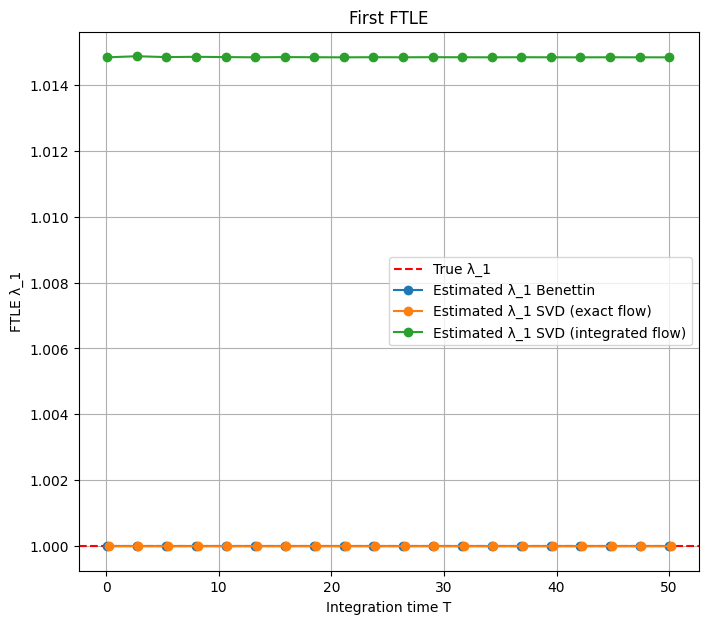

In [73]:
plt.figure(figsize=(8,7))
plt.axhline(1.0, color='r', linestyle='--', label="True λ_1")
plt.plot(T_values, lyap_estimates_qr[:,0], 'o-', label="Estimated λ_1 Benettin")
plt.plot(T_values + 0.15, lyap_estimates_svd[:,0], 'o-', label="Estimated λ_1 SVD (exact flow)")
plt.plot(T_values, lyap_estimates_svd_unk[:,0], 'o-', label="Estimated λ_1 SVD (integrated flow)")
plt.xlabel("Integration time T")
plt.ylabel("FTLE λ_1")
plt.title("First FTLE")
plt.legend()
plt.grid(True)
plt.show()

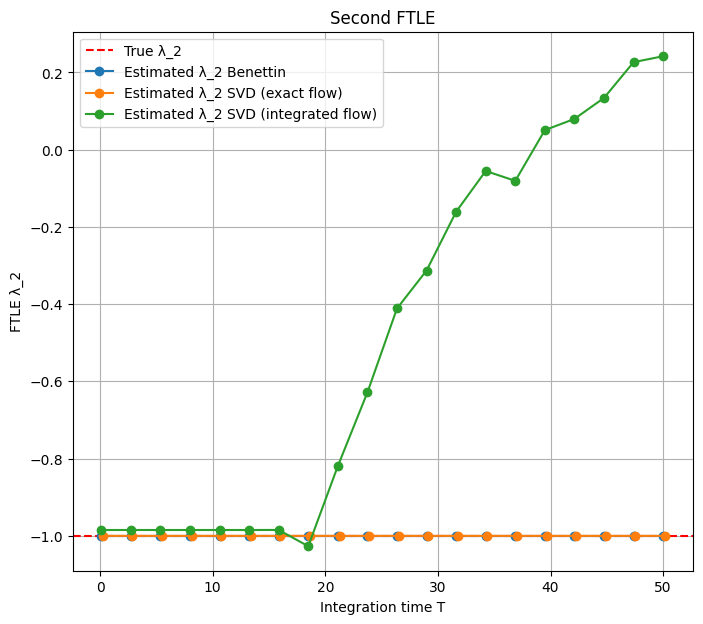

In [74]:
plt.figure(figsize=(8,7))
plt.axhline(-1.0, color='r', linestyle='--', label="True λ_2")
plt.plot(T_values, lyap_estimates_qr[:,1], 'o-', label="Estimated λ_2 Benettin")
plt.plot(T_values + 0.15, lyap_estimates_svd[:,1], 'o-', label="Estimated λ_2 SVD (exact flow)")
plt.plot(T_values, lyap_estimates_svd_unk[:,1], 'o-', label="Estimated λ_2 SVD (integrated flow)")
plt.xlabel("Integration time T")
plt.ylabel("FTLE λ_2")
plt.title("Second FTLE")
plt.legend()
plt.grid(True)
plt.show()

In [75]:
print(lyap_estimates_svd_unk[:, 0])

tensor([1.0148, 1.0149, 1.0148, 1.0148, 1.0148, 1.0148, 1.0148, 1.0148, 1.0148,
        1.0148, 1.0148, 1.0148, 1.0148, 1.0148, 1.0148, 1.0148, 1.0148, 1.0148,
        1.0148, 1.0148])


In [76]:
print(lyap_estimates_svd_unk[:, 1])

tensor([-0.9848, -0.9848, -0.9848, -0.9848, -0.9848, -0.9848, -0.9847, -1.0268,
        -0.8193, -0.6286, -0.4112, -0.3129, -0.1607, -0.0552, -0.0808,  0.0507,
         0.0796,  0.1340,  0.2266,  0.2420])


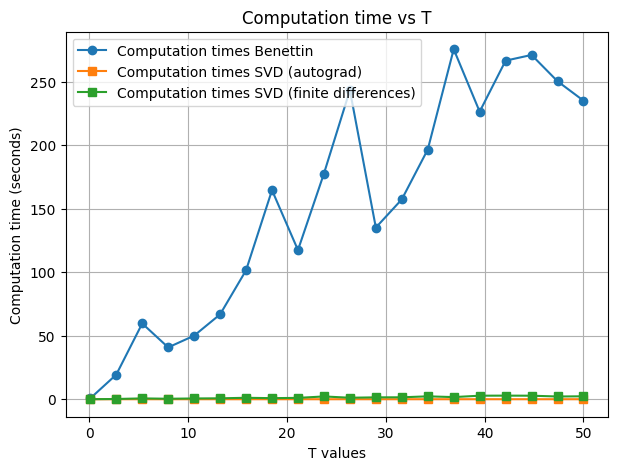

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(T_values, times_qr, 'o-', label="Computation times Benettin")
plt.plot(T_values, times_svd, 's-', label="Computation times SVD (analytical flow)")
plt.plot(T_values, times_svd_unk, 's-', label="Computation times SVD (approximated flow)")


plt.xlabel('T values')
plt.ylabel('Computation time (seconds)')
plt.title('Computation time vs T')
plt.legend()
plt.grid(True)
plt.show()